In [9]:
import matplotlib.pyplot as plt 
import json
from glob import glob

from collections import defaultdict
import os
import numpy as np

import pandas as pd


dataset_names=[
    "adult",
    "electricity",
    "forest_cover",
    "hyperplane_high_gradual_drift",
    "insects",
    "movingRBF",
    "moving_squares",
    "new_airlines",
    "rialto",
    "river_aggrawal",
    "river_anomalysine",
    "river_hyperlane_2",
    "river_hyperlane",
    "river_led",
    "river_led_default_drift",
    "river_mixed",
    "river_randomRBF_2",
    "river_randomRBF",
    "river_randomRBF_drift",
    "river_randomTree_2",
    "river_randomTree",
    "river_SEA_2",
    "river_SEA",
    "river_SINE",
    "river_STAGGER",
    "river_Waveform-2",
    "river_Waveform",
    "sea_high_abrupt_drift",
    "sea_high_mixed_drift",
    "shuttle",
    "skmul_aggrawal",
    "skmul_anomalysine_2",
    "skmul_anomalysine",
    "skmul_hyperlane",
    "skmul_ledgenerator",
    "skmul_ledgenerator_default_drift",
    "skmul_randomRBF_default_drift",
    "skmul_randomRBF_gradual",
    "skmul_randomTree_2",
    "skmul_randomTree",
    "skmul_SEA_2",
    "skmul_SEA",
    "skmul_Sine",
    "skmul_STAGGER_2",
    "skmul_STAGGER",
    "skmul_Waveform",
    "synth_agrawal",
    "synth_RandomRBFDrift",
    "vehicle_sensIT",
    "weather"
]



model_names=('HATC','ARFC','AutoClass','AutoStreamML','SRPC', 'EvoAutoML',"OnlineAutoML","ChaCha")


dataset_by_model={}
for dataset in dataset_names:
    dataset_by_model[dataset]={}

for model in model_names:
    for dataset in dataset_names:
        dataset_by_model[dataset][model]=glob(f'./experiment-results/{model}/{model}_{dataset}*')

In [ ]:
import re
import json
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from tqdm.notebook import tqdm
import re


def extract_dataset_name(filepath, framework):
    """Extract dataset name that appears between framework prefix and 'seed_'."""
    pattern = re.escape(framework) + r'_(.+?)_seed'
    match = re.search(pattern, filepath)
    return match.group(1) if match else None


def extract_config(filepath, framework):
    """Extract config parameters based on framework."""
    try:
        dataset = extract_dataset_name(filepath, framework)
        if not dataset:
            raise ValueError("Dataset name not found")

        if framework == 'AutoStreamML':
            return {
                'dataset': dataset,
                'seed': int(re.search(r'seed_(\d+)', filepath).group(1)),
                'exploration_window': int(re.search(r'exploration_window_(\d+)', filepath).group(1)),
                'ensemble_size': int(re.search(r'ensemble_size_(\d+)', filepath).group(1)),
                'budget': int(re.search(r'budget_(\d+)', filepath).group(1)),
                'framework': framework,
                'filepath': filepath
            }
        elif framework == 'EvoAutoML':
            return {
                'dataset': dataset,
                'seed': int(re.search(r'seed_(\d+)', filepath).group(1)),
                'population_size': int(re.search(r'population_size_(\d+)', filepath).group(1)),
                'sampling_size': int(re.search(r'sampling_size_(\d+)', filepath).group(1)),
                'sampling_rate': int(re.search(r'sampling_rate_(\d+)', filepath).group(1)),
                'framework': framework,
                'filepath': filepath
            }
        elif framework == 'OnlineAutoML':
            return {
                'dataset': dataset,
                'seed': int(re.search(r'seed_(\d+)', filepath).group(1)),
                'ensemble_size': int(re.search(r'ensemble_size_(\d+)', filepath).group(1)),
                'time_budget': int(re.search(r'time_budget_(\d+)', filepath).group(1)),
                'initialBatch': int(re.search(r'initialBatch_(\d+)', filepath).group(1)),
                'cache': int(re.search(r'cache_(\d+)', filepath).group(1)),
                'framework': framework,
                'filepath': filepath
            }
        elif framework == 'AutoClass':
            return {
                'dataset': dataset,
                'seed': int(re.search(r'seed_(\d+)', filepath).group(1)),
                'population_size': int(re.search(r'population_size_(\d+)', filepath).group(1)),
                'exploration_window': int(re.search(r'exploration_window_(\d+)', filepath).group(1)),
                'framework': framework,
                'filepath': filepath
            }
        elif framework == 'ChaCha':
            return {
                'dataset': dataset,
                'seed': int(re.search(r'seed_(\d+)', filepath).group(1)),
                'ensemble_size': int(re.search(r'ensemble_size_(\d+)', filepath).group(1)),
                'framework': framework,
                'filepath': filepath
            }
        else:
            raise ValueError(f"Unknown framework: {framework}")
    except Exception as e:

        return None



def process_file_wrapper(args):
    """Enhanced processor with temporal analysis for OnlineAutoML"""
    filepath, metrics, framework = args
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
            results = {'framework': framework}
            
            for metric in metrics:
                if metric in data:
                    values = np.array(data[metric])
                    
                    # Standard processing for most metrics
                    if metric != 'time' or framework != 'OnlineAutoML':
                        if metric == 'energy_consumed':
                            values *= 3600000
                        results[metric] = np.mean(values)
                    
                    # Special handling for OnlineAutoML time
                    else:
                        values *= 1000  # Convert to milliseconds
                        results.update({
                            'time': np.median(values),
                            'time_median': np.median(values),
                            'time_std': np.std(values),
                            'time_max': np.max(values),
                            'time_p90': np.percentile(values, 90),
                            'time_instability': np.mean(np.abs(np.diff(values)))  # Measures volatility
                        })
                        
                        # Add phase-specific metrics
                        split_points = [0, len(values)//3, 2*len(values)//3, len(values)]
                        for i, phase in enumerate(['early', 'mid', 'late']):
                            phase_values = values[split_points[i]:split_points[i+1]]
                            results.update({
                                f'time_{phase}_mean': np.mean(phase_values),
                                f'time_{phase}_p90': np.percentile(phase_values, 90)
                            })
            
            return results
            
    except Exception as e:

        return None

def gather_all_configs(dataset_by_model, framework, metrics=['energy_consumed', 'prequential_scores','time'], workers=4):
    """Collect configurations for a specific framework."""
    all_files = []
    for dataset in dataset_by_model.keys():
        if framework in dataset_by_model[dataset]:
            all_files.extend([(fp, metrics, framework) 
                           for fp in dataset_by_model[dataset][framework]])
    
    results = []
    with ProcessPoolExecutor(max_workers=workers) as executor:
        futures = [executor.submit(process_file_wrapper, args) for args in all_files]
        
        for i, future in enumerate(futures):
            filepath = all_files[i][0]
            metric_values = future.result()
            config = extract_config(filepath, framework)
            if config and metric_values:
                config.update(metric_values)
                results.append(config)
    
    return pd.DataFrame(results)




oaml_df = gather_all_configs(dataset_by_model, 'OnlineAutoML')
autostream_df = gather_all_configs(dataset_by_model,'AutoStreamML')
evoautoml_df = gather_all_configs(dataset_by_model,'EvoAutoML')
autoclass_df = gather_all_configs(dataset_by_model,'AutoClass')
chacha_df = gather_all_configs(dataset_by_model,'ChaCha')


In [ ]:
autostream_df.to_csv('downsized_results_csv/autostream_results.csv', index=False)
evoautoml_df.to_csv('downsized_results_csv/evoautoml_results.csv', index=False)
autoclass_df.to_csv('downsized_results_csv/autoclass_results.csv', index=False)
oaml_df.to_csv('downsized_results_csv/onlineautoml_results.csv', index=False)
chacha_df.to_csv('downsized_results_csv/chacha_results.csv', index=False)

In [1]:
import pandas as pd
autostream_df = pd.read_csv('downsized_results_csv/autostream_results.csv')
evoautoml_df=pd.read_csv('downsized_results_csv/evoautoml_results.csv')
autoclass_df=pd.read_csv('downsized_results_csv/autoclass_results.csv')
oaml_df=pd.read_csv('downsized_results_csv/onlineautoml_results.csv')
chacha_df=pd.read_csv('downsized_results_csv/chacha_results.csv')

In [8]:
import os
import matplotlib.pyplot as plt 

def analyze_parameter(df, parameter_name, protected_parameters={}, metrics=None):
    """
    Analyze the impact of a parameter on all metrics using Friedman + autorank CD plot.
    Ensures strict pairing by filtering all protected parameters and sorting by 'filepath'.

    Args:
        df: DataFrame containing the experimental results.
        parameter_name: Name of the parameter to analyze (e.g., 'budget').
        protected_parameters: Dict of fixed values for other parameters (e.g., {'ensemble_size': 3}).
        metrics: List of metrics to analyze (default: ['prequential_scores', 'energy_consumed', 'time'])
    """
    import matplotlib.pyplot as plt
    from autorank import autorank, plot_stats

    if metrics is None:
        metrics = ['prequential_scores', 'energy_consumed', 'time']

    print(f"\n=== Analyzing {df['framework'].iloc[0]} ===")
    print(f"Protected parameters: {protected_parameters}")
    print(f"Analyzing parameter: {parameter_name}")
    print(f"Available values: {sorted(df[parameter_name].unique())}")

    # Apply protected parameter filtering
    # for key, val in protected_parameters.items():
    #     df = df[df[key] == val]

    param_values = sorted(df[parameter_name].unique())

    for metric in metrics:
        try:
            print(f"\n--- Analysis for {metric} ---")
            groups = []

            for value in param_values:
                filtered = df[df[parameter_name] == value]
                filtered_metric = filtered.sort_values(by='filepath')[metric]
                groups.append(filtered_metric.reset_index(drop=True))

            # Combine groups into aligned DataFrame
            data_for_autorank = pd.DataFrame({str(v): g for v, g in zip(param_values, groups)})
            data_for_autorank = data_for_autorank.dropna()

            if data_for_autorank.shape[0] < 2:
                print("Not enough paired samples.")
                continue

            print(f"Paired samples: {data_for_autorank.shape[0]}")

            # Determine ranking direction
            if metric in ['time', 'energy_consumed']:
                order_ = 'ascending'
            else:
                order_ = 'descending'

            result = autorank(data_for_autorank, order=order_, verbose=False, force_mode='nonparametric', random_state=42)
            # print(result)

            # plot_stats(result, allow_insignificant=True,width=3)

            plot_stats(result, allow_insignificant=True)
            


            # print(ax.lines)
            # for line in ax.lines:
            #     line.set_linewidth(1.0)
            


            
            plt.tight_layout()







                        # Customize title font size
            print("METRIC", metric)
            if metric == 'prequential_scores':
                title_metric='Prequential Accuracy'
            elif metric == 'energy_consumed':
                title_metric='Energy Consumption'
            if metric == 'time':
                title_metric='Inference Time'

            if df['framework'].iloc[0]=='AutoStreamML':
                df['framework'].iloc[0]='ASML'

                
           

            
            plt.tight_layout()

            if parameter_name in ['sampling_rate', 'cache','exploration_window']:
                save_param='exploration_window'
            elif parameter_name in ['population_size']:
                save_param='population_size'
            elif parameter_name in ['ensemble_size']:
                save_param='ensemble_size'
            else:
                save_param='special'

            if save_param =='special' or save_param == 'ensemble_size' or save_param == 'population_size':
                save_path_cd=f"cd_diagrams of configs/{save_param}/{df['framework'].iloc[0]}/{metric}.png"
                plt.title(f"{title_metric}", fontsize=20)
            else:
                save_path_cd=f"cd_diagrams of configs/{save_param}/{metric}/{df['framework'].iloc[0]}.png"
                plt.title(f"{df['framework'].iloc[0]}", fontsize=20)

            print(save_path_cd)

            # Title and save
            # plt.title(f"{df['framework'].iloc[0]} - {metric}", fontsize=16)

            os.makedirs(os.path.dirname(save_path_cd), exist_ok=True)
            plt.savefig(save_path_cd, dpi=300, bbox_inches='tight')
            print(f"Saved CD diagram to {save_path_cd}")
            plt.show()

        except Exception as e:
            print(f"Error during autorank for {metric}: {str(e)}")



plt.rcParams.update({'font.size': 19})




=== Analyzing OnlineAutoML ===
Protected parameters: {}
Analyzing parameter: cache
Available values: [np.int64(1000), np.int64(2000), np.int64(3000)]

--- Analysis for prequential_scores ---
Paired samples: 254
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/exploration_window/prequential_scores/OnlineAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/prequential_scores/OnlineAutoML.png


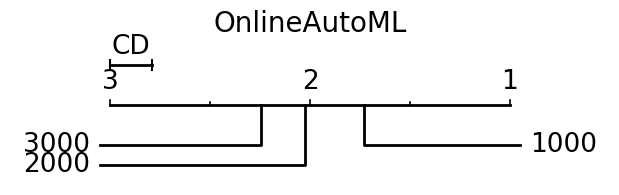


--- Analysis for energy_consumed ---
Paired samples: 254
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/exploration_window/energy_consumed/OnlineAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/energy_consumed/OnlineAutoML.png


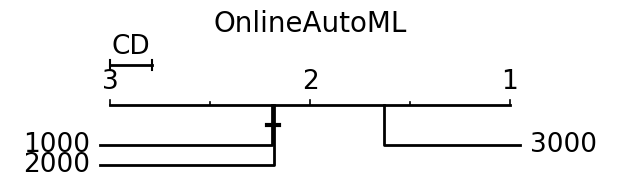


--- Analysis for time ---
Paired samples: 254
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/exploration_window/time/OnlineAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/time/OnlineAutoML.png


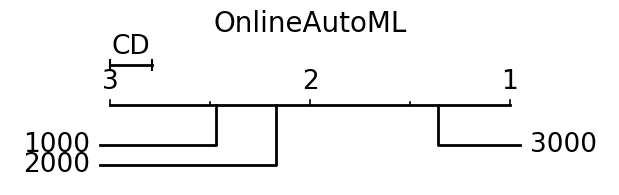


=== Analyzing EvoAutoML ===
Protected parameters: {}
Analyzing parameter: sampling_rate
Available values: [np.int64(1000), np.int64(2000), np.int64(3000)]

--- Analysis for prequential_scores ---
Paired samples: 277
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/exploration_window/prequential_scores/EvoAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/prequential_scores/EvoAutoML.png


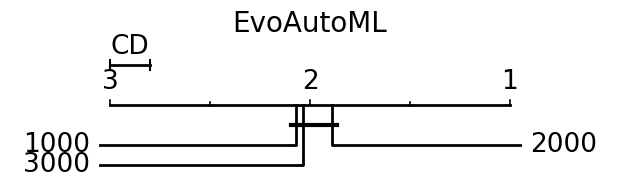


--- Analysis for energy_consumed ---
Paired samples: 277
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/exploration_window/energy_consumed/EvoAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/energy_consumed/EvoAutoML.png


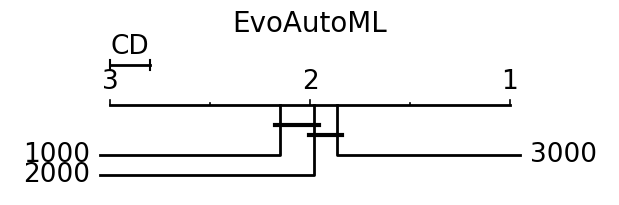


--- Analysis for time ---
Paired samples: 277
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/exploration_window/time/EvoAutoML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/time/EvoAutoML.png


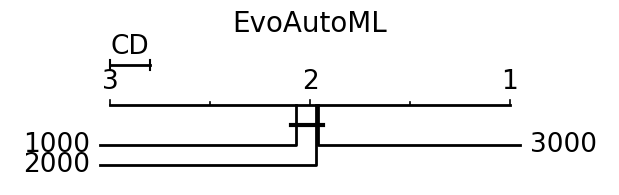


=== Analyzing AutoClass ===
Protected parameters: {}
Analyzing parameter: exploration_window
Available values: [np.int64(1000), np.int64(2000), np.int64(3000)]

--- Analysis for prequential_scores ---
Paired samples: 319
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/exploration_window/prequential_scores/AutoClass.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/prequential_scores/AutoClass.png


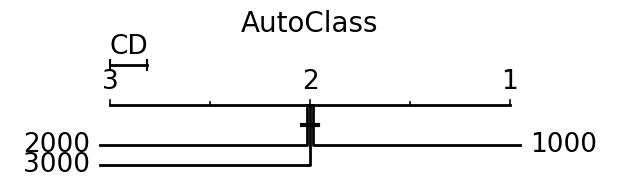


--- Analysis for energy_consumed ---
Paired samples: 319
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/exploration_window/energy_consumed/AutoClass.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/energy_consumed/AutoClass.png


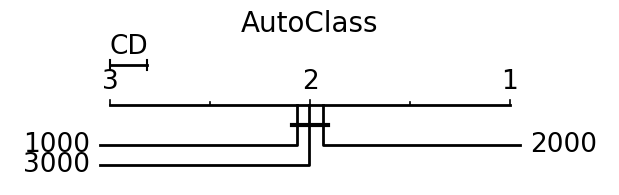


--- Analysis for time ---
Paired samples: 319
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/exploration_window/time/AutoClass.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/time/AutoClass.png


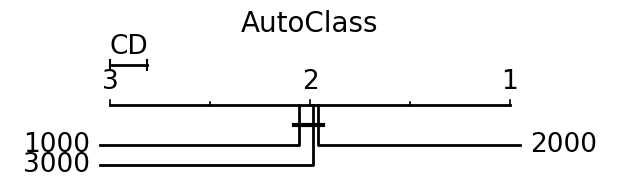


=== Analyzing ASML ===
Protected parameters: {}
Analyzing parameter: exploration_window
Available values: [np.int64(1000), np.int64(2000), np.int64(3000)]

--- Analysis for prequential_scores ---
Paired samples: 305
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/exploration_window/prequential_scores/ASML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/prequential_scores/ASML.png


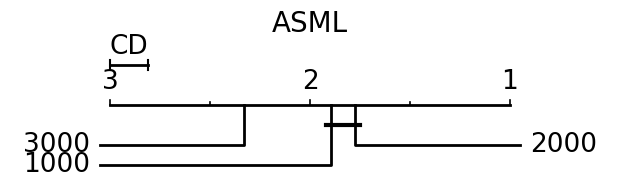


--- Analysis for energy_consumed ---
Paired samples: 305
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/exploration_window/energy_consumed/ASML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/energy_consumed/ASML.png


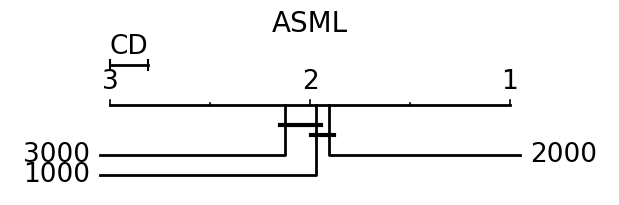


--- Analysis for time ---
Paired samples: 305
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/exploration_window/time/ASML.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/exploration_window/time/ASML.png


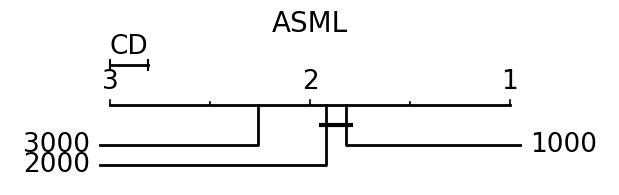

In [9]:
analyze_parameter(oaml_df, 'cache')
analyze_parameter(evoautoml_df, 'sampling_rate')
analyze_parameter(autoclass_df, 'exploration_window')
analyze_parameter(autostream_df, 'exploration_window')


=== Analyzing EvoAutoML ===
Protected parameters: {}
Analyzing parameter: population_size
Available values: [np.int64(5), np.int64(10), np.int64(20)]

--- Analysis for prequential_scores ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/population_size/EvoAutoML/prequential_scores.png
Saved CD diagram to cd_diagrams of configs/population_size/EvoAutoML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


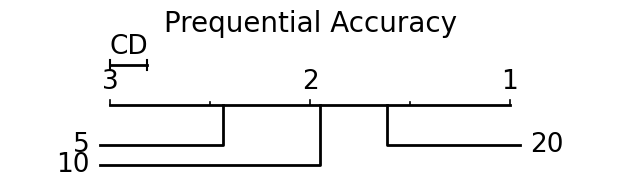


--- Analysis for energy_consumed ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/population_size/EvoAutoML/energy_consumed.png
Saved CD diagram to cd_diagrams of configs/population_size/EvoAutoML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


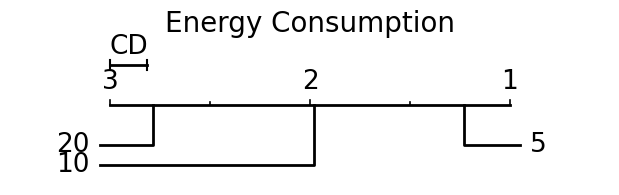


--- Analysis for time ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/population_size/EvoAutoML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/population_size/EvoAutoML/time.png


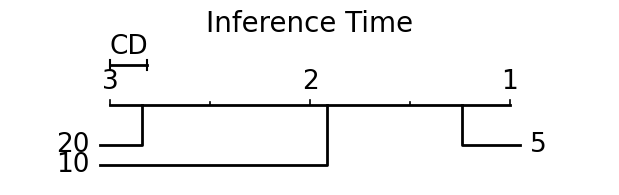


=== Analyzing AutoClass ===
Protected parameters: {}
Analyzing parameter: population_size
Available values: [np.int64(5), np.int64(10), np.int64(20)]

--- Analysis for prequential_scores ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/population_size/AutoClass/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/population_size/AutoClass/prequential_scores.png


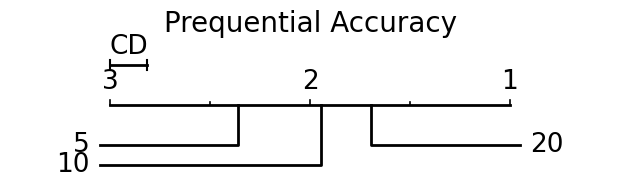


--- Analysis for energy_consumed ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/population_size/AutoClass/energy_consumed.png
Saved CD diagram to cd_diagrams of configs/population_size/AutoClass/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


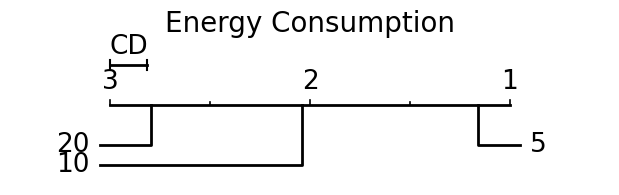


--- Analysis for time ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/population_size/AutoClass/time.png
Saved CD diagram to cd_diagrams of configs/population_size/AutoClass/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


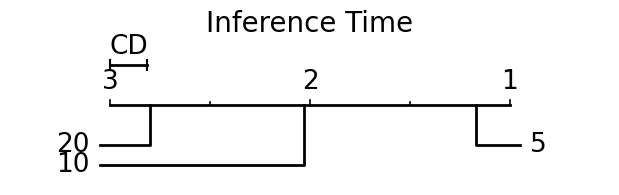


=== Analyzing OnlineAutoML ===
Protected parameters: {}
Analyzing parameter: ensemble_size
Available values: [np.int64(5), np.int64(10), np.int64(15)]

--- Analysis for prequential_scores ---
Paired samples: 256
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/ensemble_size/OnlineAutoML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/ensemble_size/OnlineAutoML/prequential_scores.png


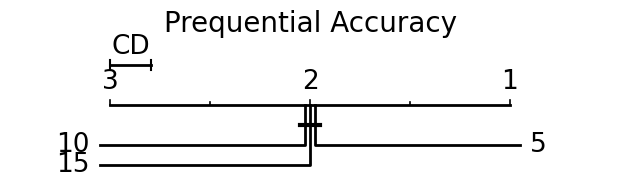


--- Analysis for energy_consumed ---
Paired samples: 256
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/ensemble_size/OnlineAutoML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/ensemble_size/OnlineAutoML/energy_consumed.png


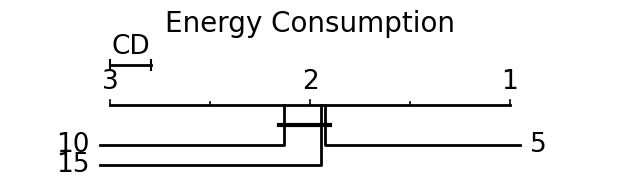


--- Analysis for time ---
Paired samples: 256
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/ensemble_size/OnlineAutoML/time.png
Saved CD diagram to cd_diagrams of configs/ensemble_size/OnlineAutoML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


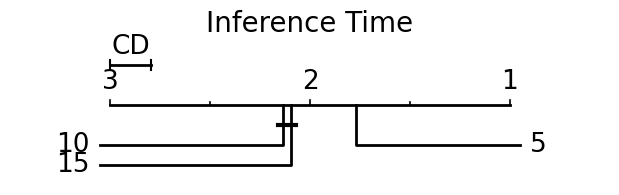


=== Analyzing ASML ===
Protected parameters: {}
Analyzing parameter: ensemble_size
Available values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

--- Analysis for prequential_scores ---
Paired samples: 299
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/ensemble_size/ASML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/ensemble_size/ASML/prequential_scores.png


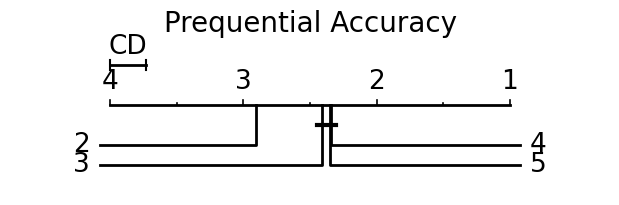


--- Analysis for energy_consumed ---
Paired samples: 299
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/ensemble_size/ASML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/ensemble_size/ASML/energy_consumed.png


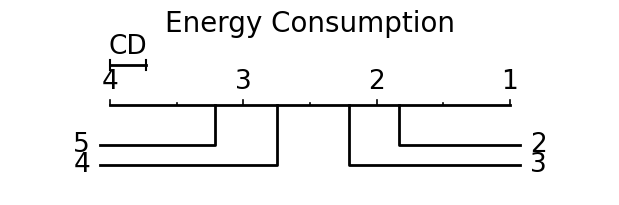


--- Analysis for time ---
Paired samples: 299
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/ensemble_size/ASML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/ensemble_size/ASML/time.png


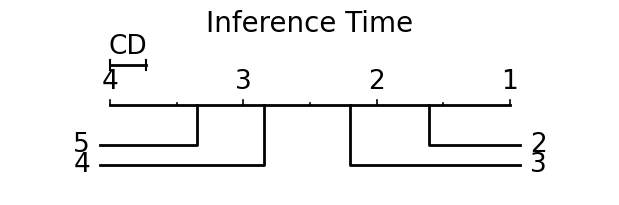


=== Analyzing ChaCha ===
Protected parameters: {}
Analyzing parameter: ensemble_size
Available values: [np.int64(5), np.int64(10), np.int64(15)]

--- Analysis for prequential_scores ---
Paired samples: 244
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/ensemble_size/ChaCha/prequential_scores.png
Saved CD diagram to cd_diagrams of configs/ensemble_size/ChaCha/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


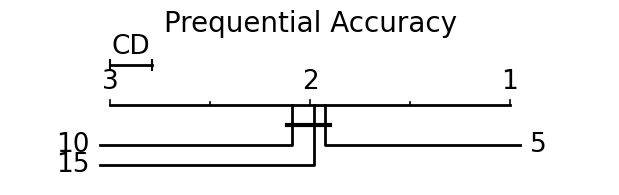


--- Analysis for energy_consumed ---
Paired samples: 244
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/ensemble_size/ChaCha/energy_consumed.png
Saved CD diagram to cd_diagrams of configs/ensemble_size/ChaCha/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


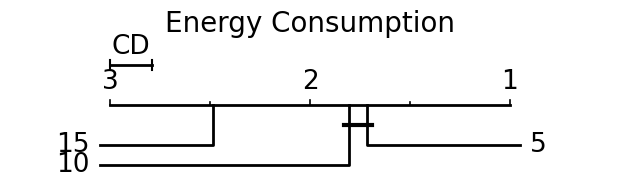


--- Analysis for time ---
Paired samples: 244
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/ensemble_size/ChaCha/time.png
Saved CD diagram to cd_diagrams of configs/ensemble_size/ChaCha/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


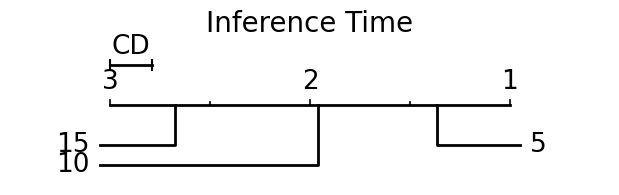

In [10]:
analyze_parameter(evoautoml_df, 'population_size')
analyze_parameter(autoclass_df, 'population_size')

analyze_parameter(oaml_df, 'ensemble_size')
analyze_parameter(autostream_df, 'ensemble_size')
analyze_parameter(chacha_df, 'ensemble_size')


=== Analyzing OnlineAutoML ===
Protected parameters: {}
Analyzing parameter: time_budget
Available values: [np.int64(30), np.int64(60), np.int64(90)]

--- Analysis for prequential_scores ---
Paired samples: 209
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/special/OnlineAutoML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/OnlineAutoML/prequential_scores.png


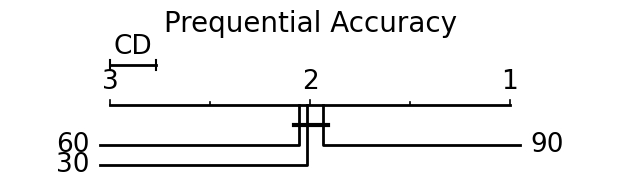


--- Analysis for energy_consumed ---
Paired samples: 209
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/special/OnlineAutoML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/OnlineAutoML/energy_consumed.png


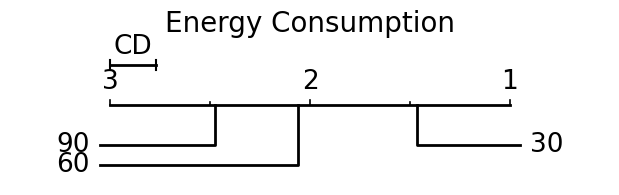


--- Analysis for time ---
Paired samples: 209
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/special/OnlineAutoML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/OnlineAutoML/time.png


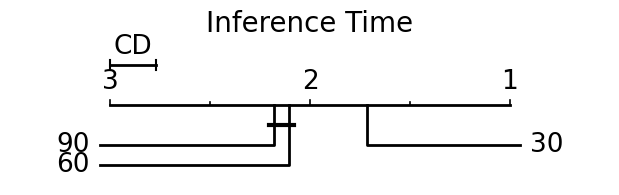


=== Analyzing EvoAutoML ===
Protected parameters: {}
Analyzing parameter: sampling_size
Available values: [np.int64(1), np.int64(2), np.int64(3)]

--- Analysis for prequential_scores ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/special/EvoAutoML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/EvoAutoML/prequential_scores.png


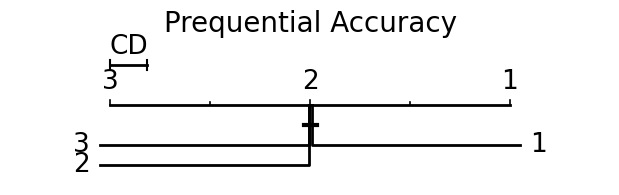


--- Analysis for energy_consumed ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/special/EvoAutoML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/EvoAutoML/energy_consumed.png


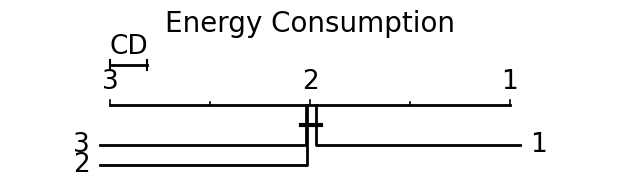


--- Analysis for time ---
Paired samples: 314
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/special/EvoAutoML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/EvoAutoML/time.png


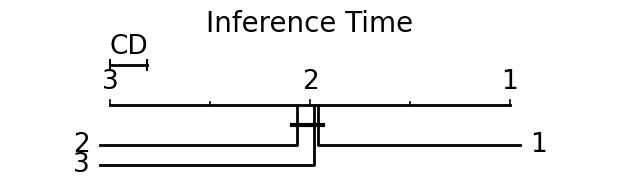


=== Analyzing ASML ===
Protected parameters: {}
Analyzing parameter: budget
Available values: [np.int64(5), np.int64(10), np.int64(15)]

--- Analysis for prequential_scores ---
Paired samples: 272
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC prequential_scores
cd_diagrams of configs/special/ASML/prequential_scores.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/ASML/prequential_scores.png


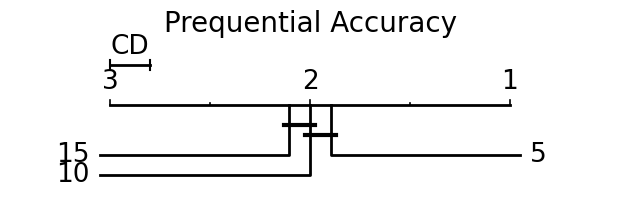


--- Analysis for energy_consumed ---
Paired samples: 272
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC energy_consumed
cd_diagrams of configs/special/ASML/energy_consumed.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/ASML/energy_consumed.png


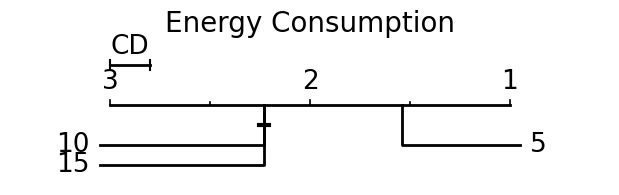


--- Analysis for time ---
Paired samples: 272
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
METRIC time
cd_diagrams of configs/special/ASML/time.png


/tmp/ipykernel_1490050/813205358.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1490050/813205358.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved CD diagram to cd_diagrams of configs/special/ASML/time.png


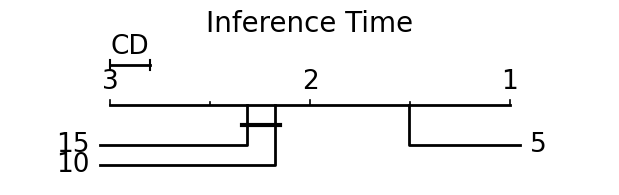

In [11]:
analyze_parameter(oaml_df, 'time_budget')
analyze_parameter(evoautoml_df, 'sampling_size')
analyze_parameter(autostream_df, 'budget')